In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as st

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv("/content/drive/MyDrive/Statistics/3campain.csv")
data.head(10)

,Campain,Sell
0,A,12.6
1,A,12.0
2,A,11.8
3,A,11.9
4,A,13.0
5,A,12.5
6,A,14.0
7,B,10.0
8,B,10.2
9,B,10.0


In [6]:
print(f"Mean of Sells: {data['Sell'].mean()}")
print(f"Std of Sells: {data['Sell'].std()}")

Mean of Sells: 11.980952380952381
Std of Sells: 1.4685431718608235


In [7]:
data.groupby("Campain")["Sell"].mean()

,Sell
Campain,
A,12.542857
B,11.533333
C,11.825000


In [8]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [9]:
result = ols("Sell ~ Campain", data=data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   Sell   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.8213
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.456
Time:                        17:40:26   Log-Likelihood:                -36.438
No. Observations:                  21   AIC:                             78.88
Df Residuals:                      18   BIC:                             82.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.5429      0.560     22.395   

In [10]:
sm.stats.anova_lm(result)

,df,sum_sq,mean_sq,F,PR(>F)
Campain,2.0,3.606905,1.803452,0.821297,0.455683
Residual,18.0,39.525476,2.195860,NaN,NaN


In [11]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Sell   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.8213
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.456
Time:                        17:40:26   Log-Likelihood:                -36.438
No. Observations:                  21   AIC:                             78.88
Df Residuals:                      18   BIC:                             82.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.5429      0.560     22.395      0.000      11.366      13.720
Campain[T.B]    -1.0095      0.824     -1.225      0.237      -2.742       0.723
Campain[T.C]    -0.7179      0.767     -0.936      0.362      -2.329       0.893
==============================================================================
Omnibus:                        0.586   Durbin-Watson:                   1.805
Prob(Omnibus):                  0.746   Jarque-Bera (JB):                0.633
Skew:                          -0.151   Prob(JB):                        0.729
Kurtosis:                       2.205   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
data["Mean"] = data["Sell"].mean()

In [13]:
data

,Campain,Sell,Mean
0,A,12.6,11.980952
1,A,12.0,11.980952
2,A,11.8,11.980952
3,A,11.9,11.980952
4,A,13.0,11.980952
5,A,12.5,11.980952
6,A,14.0,11.980952
7,B,10.0,11.980952
8,B,10.2,11.980952
9,B,10.0,11.980952


In [14]:
sum_sq = sum((data["Sell"] - data["Mean"])**2)
sum_sq

43.132380952380956

In [15]:
gMean = data.groupby("Campain")["Sell"].mean()
type(gMean)

pandas.core.series.Series

In [16]:
gMean = data.groupby("Campain").mean()[["Sell"]]
type(gMean)

pandas.core.frame.DataFrame

In [17]:
gMean = gMean.rename(columns={'Sell': 'gMean'})
gMean


,gMean
Campain,
A,12.542857
B,11.533333
C,11.825000


In [18]:
gMean.index.to_list()

['A', 'B', 'C']

In [19]:
data_merge = data.merge(gMean, left_on="Campain", right_index=True)
data_merge

,Campain,Sell,Mean,gMean
0,A,12.6,11.980952,12.542857
1,A,12.0,11.980952,12.542857
2,A,11.8,11.980952,12.542857
3,A,11.9,11.980952,12.542857
4,A,13.0,11.980952,12.542857
5,A,12.5,11.980952,12.542857
6,A,14.0,11.980952,12.542857
7,B,10.0,11.980952,11.533333
8,B,10.2,11.980952,11.533333
9,B,10.0,11.980952,11.533333


In [20]:
ss_reg = sum((data_merge["Sell"] - data_merge["gMean"])**2)
ss_error = sum((data_merge["Mean"] - data_merge["gMean"])**2)

print(f"Sum of Squares for Regression: {ss_reg}")
print(f"Sum of Squares for Error: {ss_error}")

Sum of Squares for Regression: 39.52547619047619
Sum of Squares for Error: 3.606904761904763


In [21]:
anova_table = sm.stats.anova_lm(result)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
Campain,2.0,3.606905,1.803452,0.821297,0.455683
Residual,18.0,39.525476,2.195860,NaN,NaN


In [22]:
ms_reg = ss_reg / anova_table['df']['Residual']
ms_error = ss_error / anova_table['df']['Campain']
print(f"Mean Square for Regression: {ms_reg}")
print(f"Mean Square for Error: {ms_error}")

Mean Square for Regression: 2.1958597883597886
Mean Square for Error: 1.8034523809523815


In [23]:
f = ms_error / ms_reg
print(f"F-Statistic: {f}")

F-Statistic: 0.8212966923081558


In [25]:
p = 1 - st.stats.f.cdf(f, anova_table['df']['Campain'], anova_table['df']['Residual'])
print(f"P-Value: {p}")

P-Value: 0.4556832940515235


In [27]:
data = st.stats.f.rvs(anova_table['df']['Campain'], anova_table['df']['Residual'], size=10000)

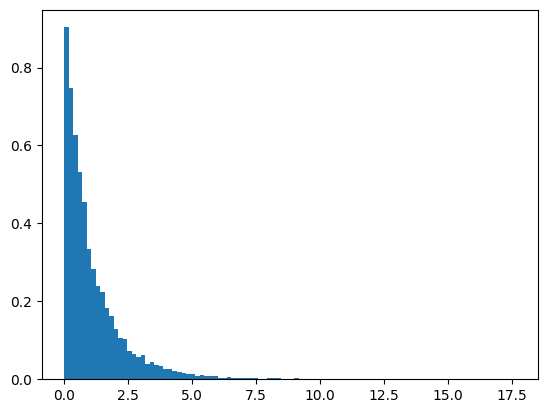

In [30]:
plt.hist(data, bins=100, density=True)
plt.show()